## Introduction
In this notebook we show how to use the modal interpolant construction to build a straight-line flow the connects univariate Gaussians.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import optimalinterp as oi

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", True)

## 1. Problem Setup
We start by building the problem. The core object here is the "StochasticBasis" which defined the family $(Z_\alpha)_{\alpha=1}^N$ of random variables that interpolates between the source and target measures.
Namely, by construction we have
$$ Z_0 \overset{d}{=} X_0 \quad Z_N \overset{d}{=} X_1 $$
where $X_0 \sim \mu$ and $X_1 \sim \nu$ are the source and target measures respectively.

In this example we work in $d=1$ dimensions and take the source to be a standard normal and the target to be a Gaussian with some mean and covariance.

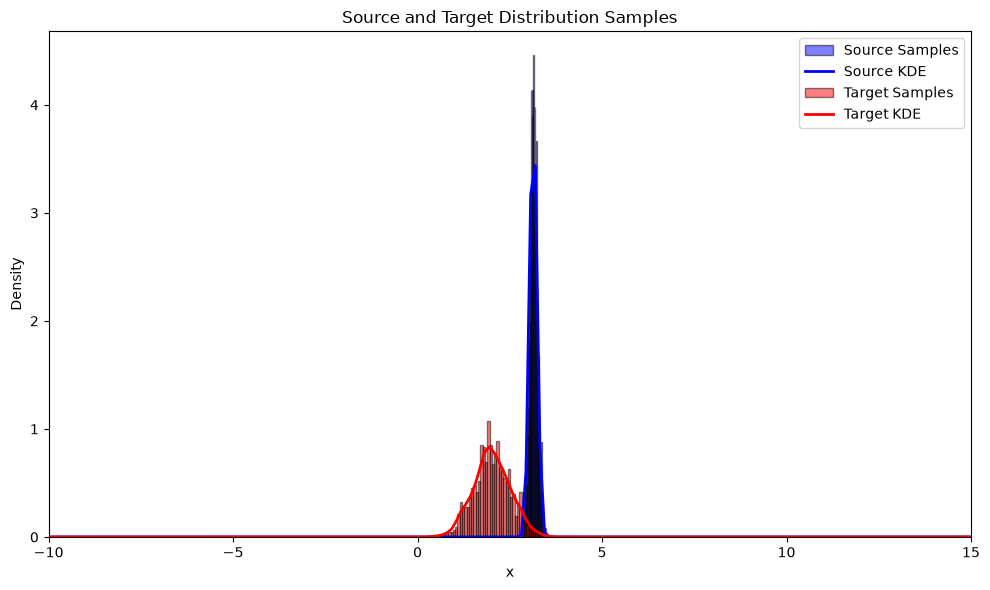

In [2]:
# Generate samples to plot the source and target distributions
n_samples = 1000

key = jax.random.PRNGKey(0)
N_modes, max_period_idx = 4, 1
stochastic_basis = oi.WrappedGaussianConvolutionBasis(
    N_modes,
    max_period_idx,
    mean_0=jnp.pi,
    std_dev_0=0.1,
    mean_1=2.0,
    std_dev_1=0.5,
)
samples = stochastic_basis.sample(N_samples=1000, key=key)
source_samples = samples[:, 0]
target_samples = samples[:, -1]

# Plot samples with KDE on the same plot

fig, ax = plt.subplots(figsize=(10, 6))

# Source distribution
ax.hist(
    source_samples,
    bins=50,
    density=True,
    alpha=0.5,
    color="blue",
    edgecolor="black",
    label="Source Samples",
)
kde_source = gaussian_kde(source_samples)
x_range = jnp.linspace(-10, 15, 200)
ax.plot(x_range, kde_source(x_range), color="blue", linewidth=2, label="Source KDE")

# Target distribution
ax.hist(
    target_samples,
    bins=50,
    density=True,
    alpha=0.5,
    color="red",
    edgecolor="black",
    label="Target Samples",
)
kde_target = gaussian_kde(target_samples)
ax.plot(x_range, kde_target(x_range), color="red", linewidth=2, label="Target KDE")

ax.set_title("Source and Target Distribution Samples")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_xlim(-10, 15)
ax.legend()

plt.tight_layout()
plt.show()

Now we proceed by building an optimal interpolant object.
Note that upon instantiation, one *will not* be able to call the interpolant, as the
coefficients $t \mapsto \psi(t)$ have not yet been computed.

However, before we build an optimal interpolant we build a *standard stochastic interpolant*
to give ourselves a point of comparison. That is, we instantiate the stochastic interpolant
$$ X_t = (1 - t) X_0 + t X_1 $$

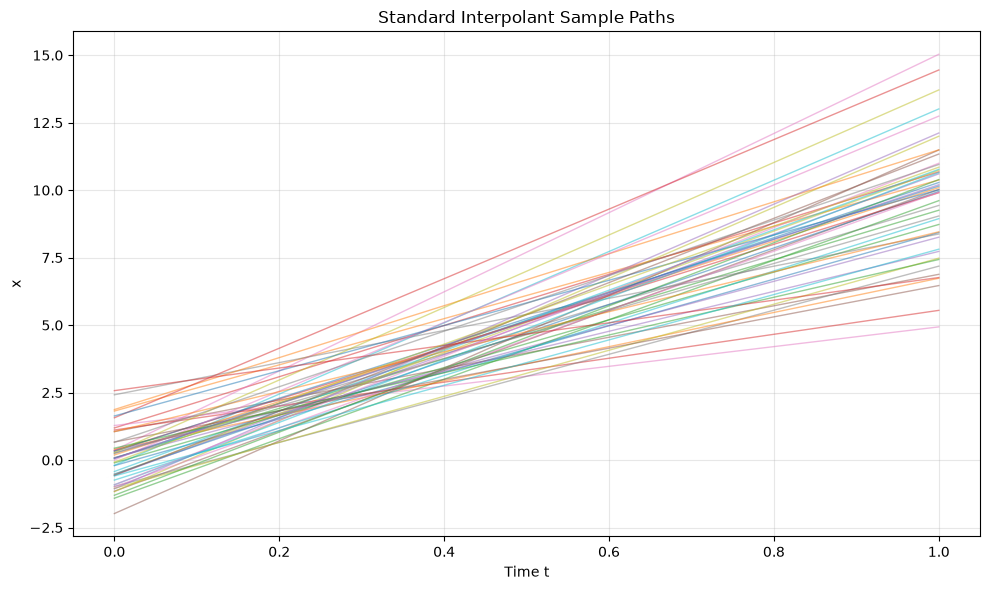

In [3]:
simple_stochastic_basis = oi.GaussianConvolutionBasis(
    N_modes=2,
    mean=10.0,
    std_dev=2.0,
)

simple_psi = jnp.array(
    [
        jnp.linspace(1, 0, 100),
        jnp.linspace(0, 1, 100),
    ]
).T

standard_interpolant = oi.modal_interpolant_factory(
    "time interpolated",
    t=jnp.linspace(0, 1, 100),  # 100 time points
    Z=simple_stochastic_basis,
    psi=simple_psi,
    psi_dot=jnp.ones((100,2))
)

# Plot sample paths of the standard interpolant
n_paths = 50
t_eval = jnp.linspace(0, 1, 100)
key = jax.random.PRNGKey(0)

# Shape: (n_paths, n_times)
sample_paths = standard_interpolant(key, n_paths)

fig, ax = plt.subplots(figsize=(10, 6))
t_vals = standard_interpolant.default_tgrid()

for i in range(n_paths):
    ax.plot(t_vals, sample_paths[i, :], alpha=0.5, linewidth=1)

ax.set_title("Standard Interpolant Sample Paths")
ax.set_xlabel("Time t")
ax.set_ylabel("x")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Compute Optimal Coefficients
Next, we compute the optimal coefficients $t \mapsto \psi(t)$ for the optimal interpolant.
This is done by calling the `compute_optimal_psi` method.

Step: 0, Accepted steps: 0, Steps since acceptance: 0, Loss on this step: 1.0, Loss on the last accepted step: 0.0, Step size: 1.0, y: [0. 0. 0. 0.], y on the last accepted step: [0. 0. 0. 0.]
Step: 1, Accepted steps: 1, Steps since acceptance: 0, Loss on this step: inf, Loss on the last accepted step: 1.0, Step size: 0.25, y: [-0.5  0.   0.   0.5], y on the last accepted step: [0. 0. 0. 0.]
Step: 2, Accepted steps: 1, Steps since acceptance: 1, Loss on this step: inf, Loss on the last accepted step: 1.0, Step size: 0.0625, y: [-0.2  0.   0.   0.2], y on the last accepted step: [0. 0. 0. 0.]
Step: 3, Accepted steps: 1, Steps since acceptance: 2, Loss on this step: inf, Loss on the last accepted step: 1.0, Step size: 0.015625, y: [-0.05882353  0.          0.          0.05882353], y on the last accepted step: [0. 0. 0. 0.]
Step: 4, Accepted steps: 1, Steps since acceptance: 3, Loss on this step: inf, Loss on the last accepted step: 1.0, Step size: 0.00390625, y: [-0.01538462  0.         

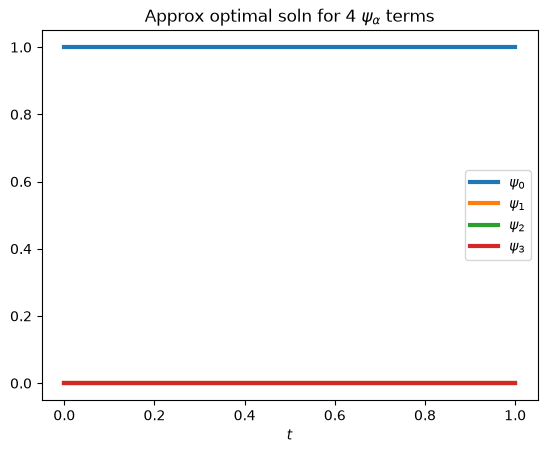

In [4]:
# N_test = 2*stochastic_basis.N_modes
N_test = 5 # Choose number of test functions
optimal_interpolant = oi.optimal_interpolant.compute_optimal_psi_shooting(
    stochastic_basis, allow_failure=True, N_test=N_test,
    max_optimizer_steps=1000, rtol=1e-15, atol=1e-15
)

## 3. Visualize Sample Paths and mean velocity.
We start by plotting the sample paths of the optimal interpolant.

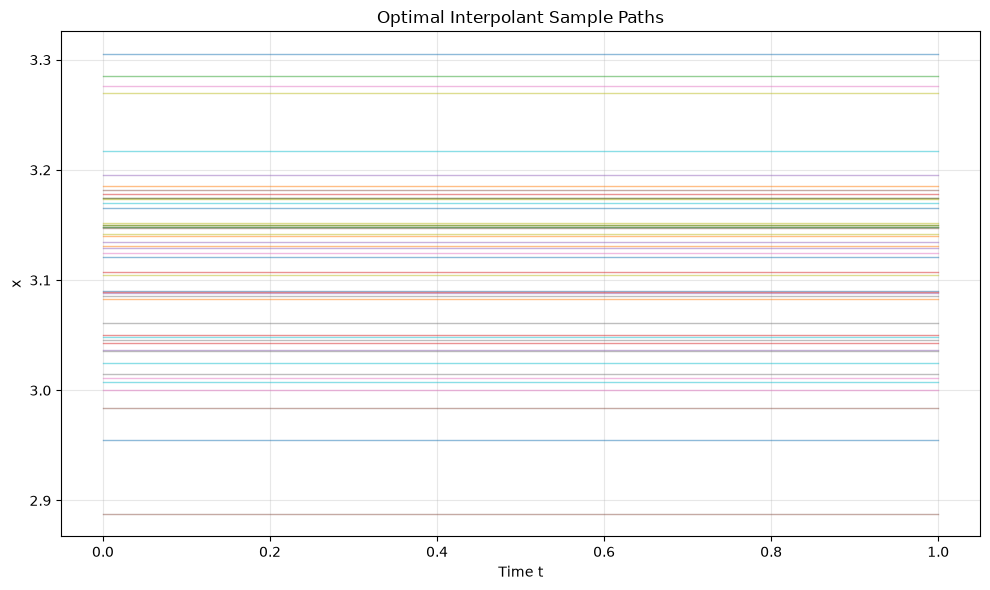

In [5]:
n_paths = 50
t_eval = jnp.linspace(0, 1, 103)
key = jax.random.PRNGKey(0)
sample_paths = optimal_interpolant(
    N_samples=n_paths, key=key, t_eval=t_eval
)  # Shape: (n_paths, n_times)

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(n_paths):
    ax.plot(t_eval, sample_paths[i, :], alpha=0.5, linewidth=1)

ax.set_title("Optimal Interpolant Sample Paths")
ax.set_xlabel("Time t")
ax.set_ylabel("x")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Finally, we can compute and visualize the mean velocity field induced by the optimal interpolant.
We use the `interpolate_velocity_field` utility function for this purpose.

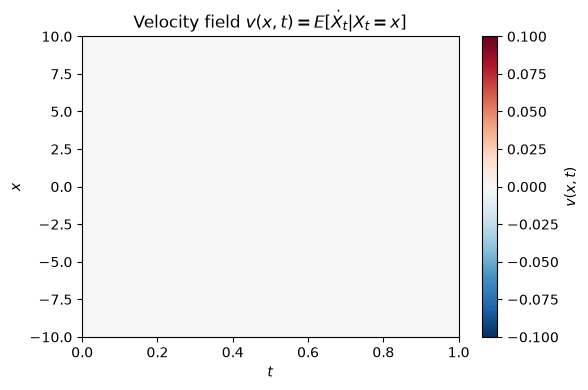

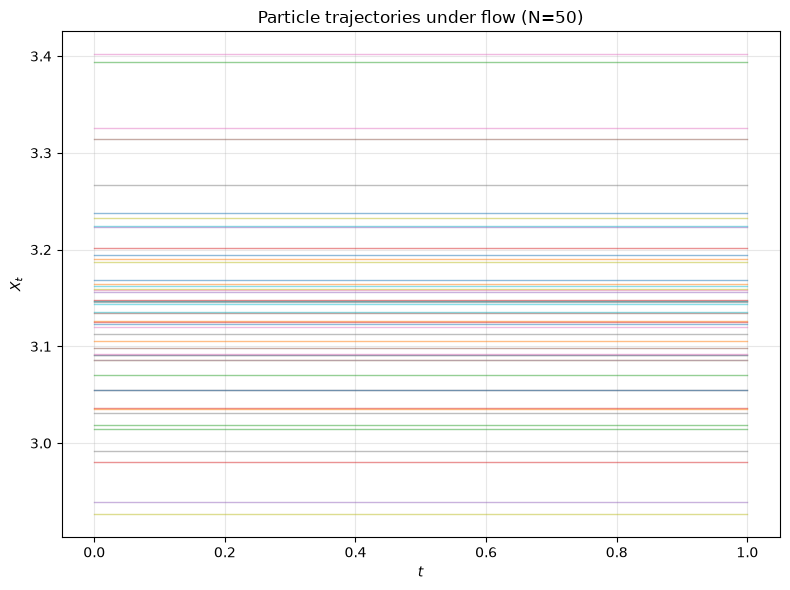

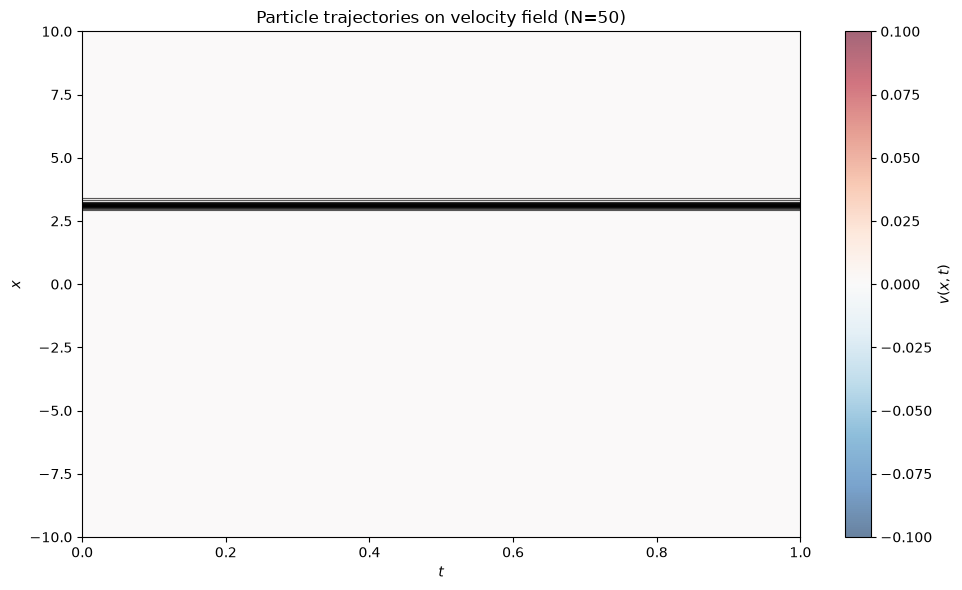

In [6]:
key = jax.random.PRNGKey(42)
x_grid = jnp.linspace(-10, 10, 101)
oi.visualization.visualize_interpolant_flow(
    optimal_interpolant,
    key,
    x_grid,
    bin_width=0.2,
    kernel_type="gaussian",
    N_velocity_samples=15000,
    N_flow_samples=50,
)